# API structure


# Pricing using the Binomial Tree and BSM Engine


In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))


import numpy as np
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData, DividendEvent
from quantkit.pricing.core.pricer import Pricer
from quantkit.pricing.utils.visualization import *
from quantkit.pricing.utils.graphs import *

# Base No-Dividend Market
market_no_div = MarketData(spot=100.0, rate=0.05, volatility=0.2)

# Base Dividend Market
divs = [DividendEvent(time=0.5, amount=2.0), DividendEvent(time=0.8, amount=2.0)]
market_div = MarketData(spot=100.0, rate=0.05, volatility=0.2, discrete_dividends=divs)

eur_call = Option(100.0, 1.0, OptionType.CALL, OptionStyle.EUROPEAN)
eur_put = Option(100.0, 1.0, OptionType.PUT, OptionStyle.EUROPEAN)
am_call = Option(100.0, 1.0, OptionType.CALL, OptionStyle.AMERICAN)
am_put = Option(100.0, 1.0, OptionType.PUT, OptionStyle.AMERICAN)

## 1. Example - to show output + show plots for the same

One example each for European call, put and American call, put - print out the price, and add a graph for exercise boundaries (graphs should also show the param values)

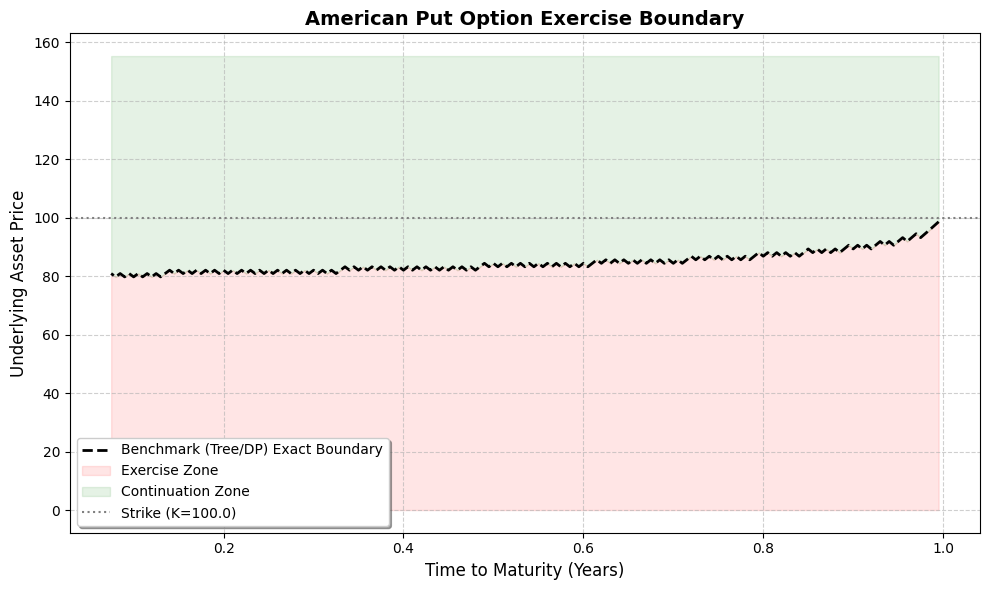

In [2]:
eur_call_example = Pricer.price(eur_call, market_no_div, engine='bsm')
am_put_example = Pricer.price(am_put, market_no_div, engine='binomial', steps=200)
am_call_example = Pricer.price(am_call, market_no_div, engine='binomial', steps=200)

plot_exercise_boundary_binomial_bsm(am_put, am_put_example, title="American Put Option Exercise Boundary")

## 2. Convergence Analysis

### 2.1 Binomial Tree - Steps versus Price (error) 

1. no dividends - European/American call, European puts - compare with BSM price by plotting stpes vs price errorr
2. American puts - just plot prices with steps


### 2.2 Time (because of number of steps) vs Price error
Same as above - Find a way to compare some runtime/computational complexity with price error (for no dividend case)

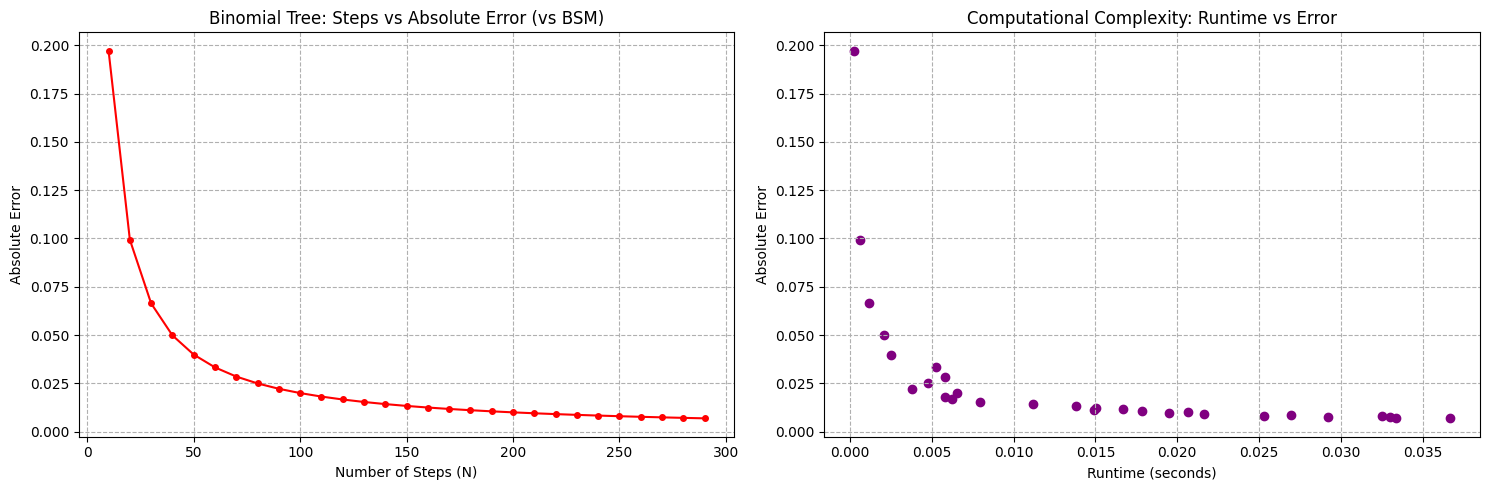

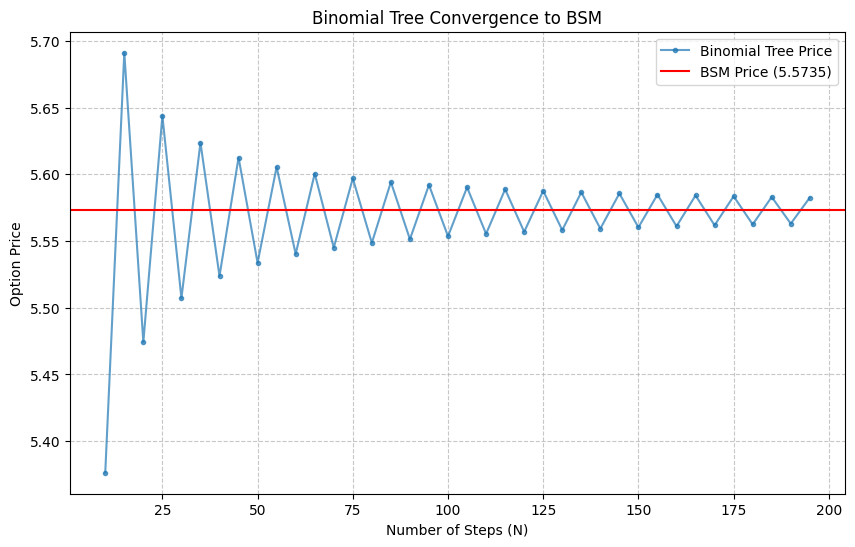

In [3]:
# 2.1 & 2.2: Binomial Tree Steps vs Price Error AND Runtime vs Error
plot_convergence_error_and_time(eur_put, market_no_div, step_range=range(10, 300, 10))

# For American Puts, BSM isn't accurate, so we just plot price vs steps
plot_binomial_convergence(eur_put, market_no_div, step_range=range(10, 200, 5)) # Proxy test

## 3. Graphs for both Put and call - assuming no dividends, for everything

1. Delta 
2. Theta
3. Vega
4. Rho 


INCLUDE THIS IMPORTANT CASE FOR THETA = deep ITM European Puts

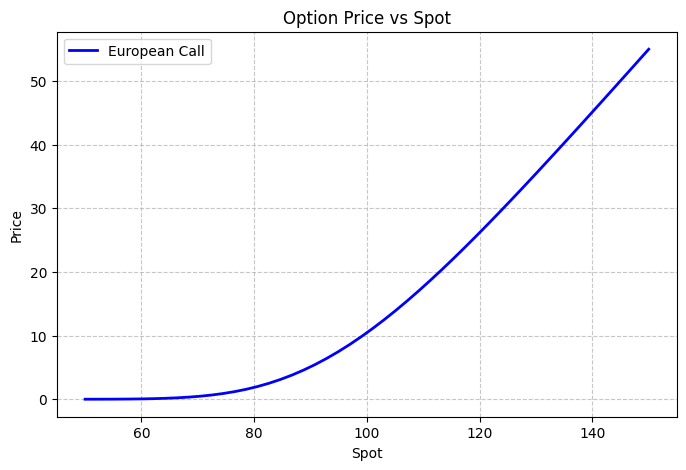

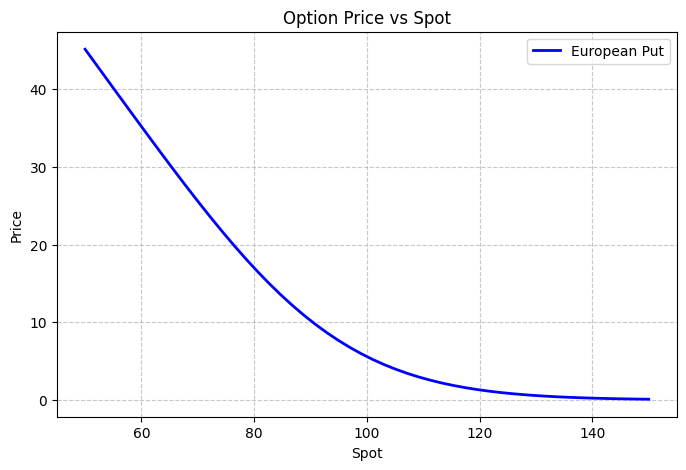

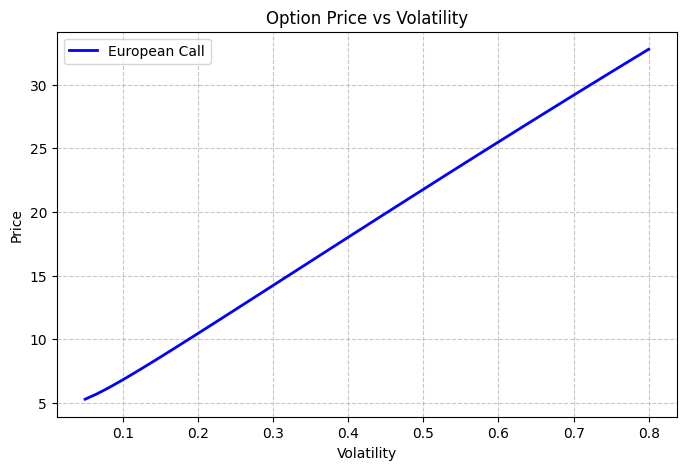

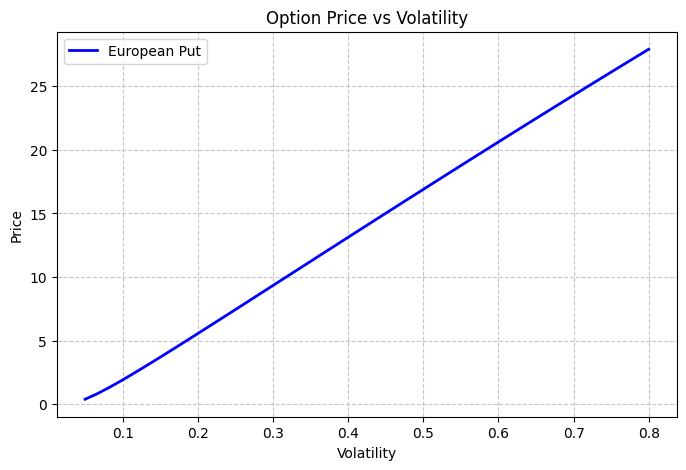

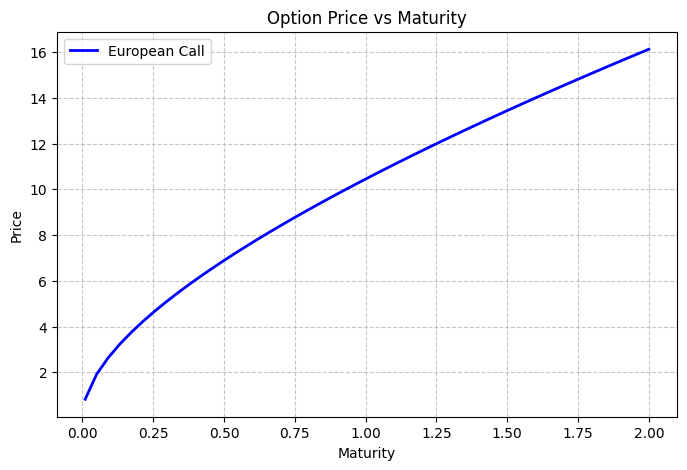

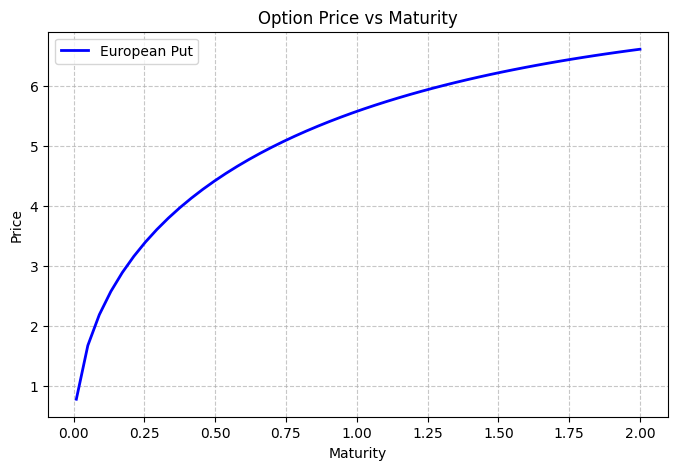

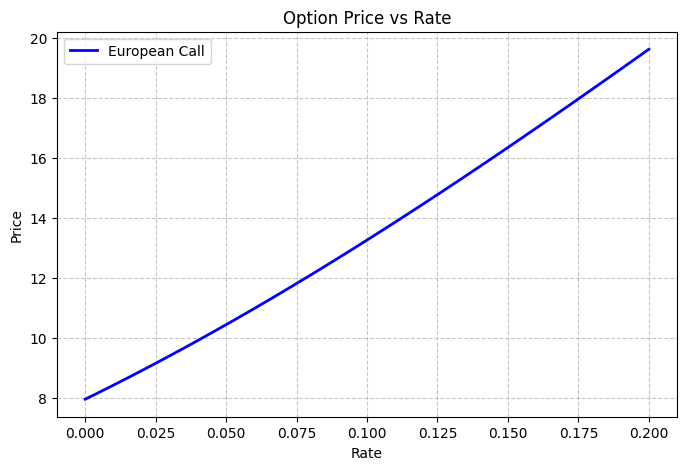

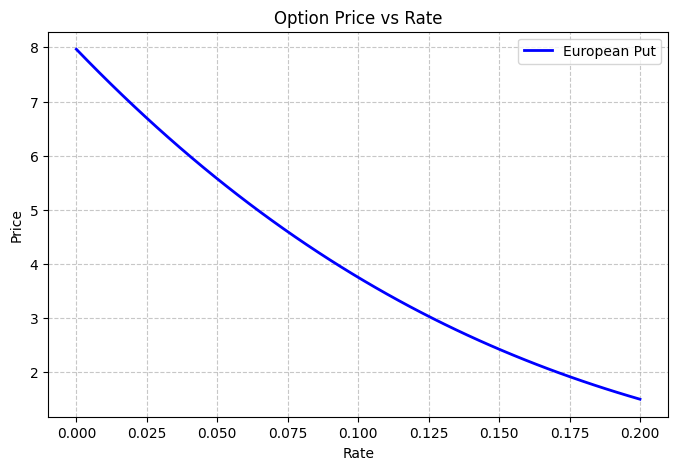

Deep ITM European Put for Theta:


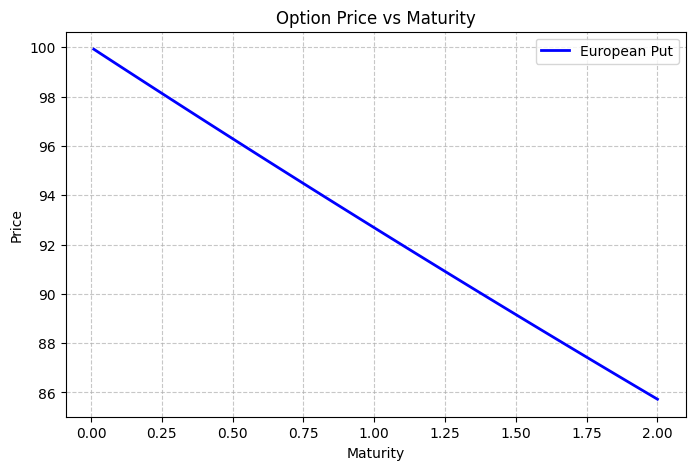

In [4]:
spot_range = np.linspace(50, 150, 50)
vol_range = np.linspace(0.05, 0.8, 50)
time_range = np.linspace(0.01, 2.0, 50)
rate_range = np.linspace(0.0, 0.2, 50)

# Delta Proxy
plot_sensitivities(eur_call, market_no_div, 'spot', spot_range, engine="bsm")
plot_sensitivities(eur_put, market_no_div, 'spot', spot_range, engine="bsm")

# Vega Proxy
plot_sensitivities(eur_call, market_no_div, 'volatility', vol_range, engine="binomial", steps=200)
plot_sensitivities(eur_put, market_no_div, 'volatility', vol_range, engine="binomial", steps=200)

# Theta Proxy
plot_sensitivities(eur_call, market_no_div, 'maturity', time_range, engine="bsm")
plot_sensitivities(eur_put, market_no_div, 'maturity', time_range, engine="bsm")    

# Rho Proxy
plot_sensitivities(eur_call, market_no_div, 'rate', rate_range, engine="bsm")
plot_sensitivities(eur_put, market_no_div, 'rate', rate_range, engine="bsm")



print("Deep ITM European Put for Theta:")
# IMPORTANT CASE: Deep ITM European Put for Theta
# Notice how the curve bends upward as time approaches 0 (meaning positive theta!)
deep_itm_put = Option(strike=150.0, maturity=2.0, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN)
market_low_spot = MarketData(spot=50.0, rate=0.05, volatility=0.2)
plot_sensitivities(deep_itm_put, market_low_spot, 'maturity', time_range, engine="bsm")

## 4. Put call parity for European - with and without dividends with maybe 5 examples - show in a table

In [5]:
examples = [
    {'strike': 90.0, 'maturity': 0.5},
    {'strike': 100.0, 'maturity': 1.0},
    {'strike': 110.0, 'maturity': 1.0},
    {'strike': 100.0, 'maturity': 2.0},
    {'strike': 120.0, 'maturity': 0.25}
]

print("--- WITHOUT Dividends ---")
display(generate_put_call_parity_table(market_no_div, examples))

print("\n--- WITH Discrete Dividends ---")
display(generate_put_call_parity_table(market_div, examples))

--- WITHOUT Dividends ---


,Strike,Maturity,Call Price,Put Price,C - P (LHS),S - PV(K) - PV(Div) (RHS),Diff (Error)
0,90.0,0.50,13.4985,1.2764,12.2221,12.2221,0.0
1,100.0,1.00,10.4506,5.5735,4.8771,4.8771,0.0
2,110.0,1.00,6.0401,10.6753,-4.6352,-4.6352,0.0
3,100.0,2.00,16.1268,6.6105,9.5163,9.5163,0.0
4,120.0,0.25,0.1998,18.7091,-18.5093,-18.5093,0.0



--- WITH Discrete Dividends ---


,Strike,Maturity,Call Price,Put Price,C - P (LHS),S - PV(K) - PV(Div) (RHS),Diff (Error)
0,90.0,0.50,13.4985,1.2764,12.2221,12.2221,0.0
1,100.0,1.00,8.1300,7.1252,1.0049,1.0049,0.0
2,110.0,1.00,4.4475,12.9550,-8.5074,-8.5074,0.0
3,100.0,2.00,13.5530,7.9089,5.6441,5.6441,0.0
4,120.0,0.25,0.1998,18.7091,-18.5093,-18.5093,0.0


## 5. Plots for bounds 

Show bounds + price as the spot price varies - graph should be spot price vs price for a fixed K, r and volatility. Plot the price, upper and lower bounds
for both BSM and binomial (relatively high Number of steps)

Plot for 
1. Binomial - European call, put with and without discrete dividends + American call,put with discrete dividends,
2. BSM - Europen call put - with and without continuous yield

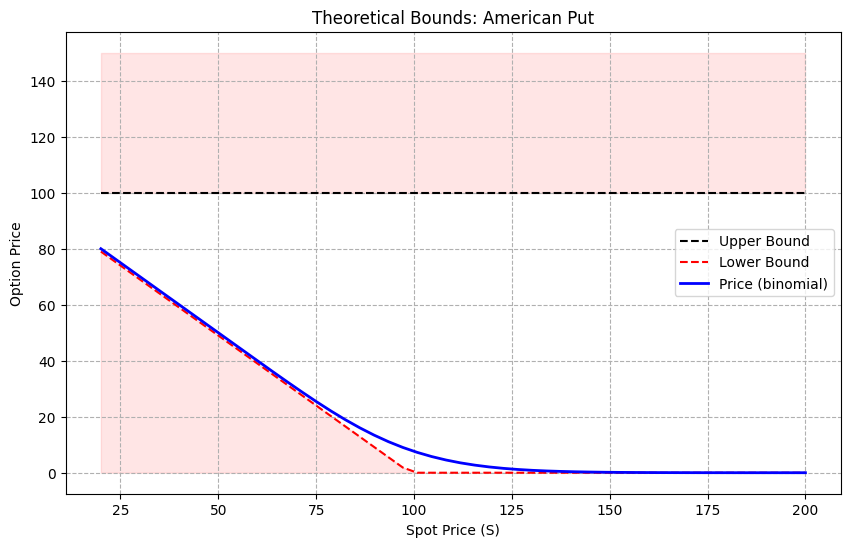

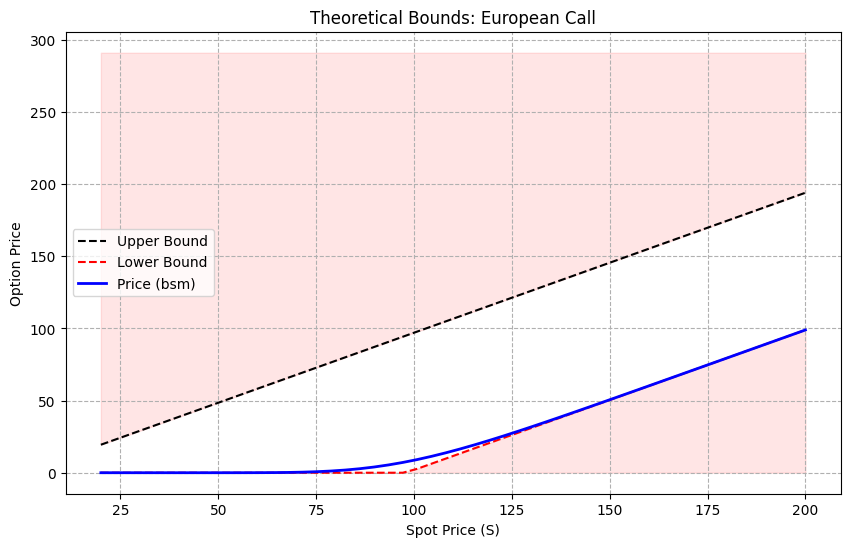

In [6]:
spot_range = np.linspace(20, 200, 50)

# 1. Binomial - American Put with discrete dividends
plot_price_bounds(am_put, market_div, spot_range, engine="binomial", steps=150)

# 2. BSM - European Call with continuous yield
market_yield = MarketData(spot=100.0, rate=0.05, volatility=0.2, dividend_yield=0.03)
plot_price_bounds(eur_call, market_yield, spot_range, engine="bsm")

## 6.  P >= p - no dividends

1. Show as a table for different params

In [7]:
# Show as a table for different params[cite: 18]
strikes = [90, 100, 110]
maturities = [0.5, 1.0, 2.0]

df_premium = generate_american_vs_european_table(market_no_div, strikes, maturities, OptionType.PUT)
display(df_premium) #[cite: 19]

,Type,Strike,Maturity,European Price,American Price,Early Exercise Premium,Invariant Holds?
0,Put,90,0.5,1.2813,1.3288,0.0475,True
1,Put,90,1.0,2.3128,2.4745,0.1617,True
2,Put,90,2.0,3.4752,3.9427,0.4675,True
3,Put,100,0.5,4.4103,4.6514,0.2411,True
4,Put,100,1.0,5.5602,6.0850,0.5248,True
5,Put,100,2.0,6.5917,7.7158,1.1241,True
6,Put,110,0.5,10.1872,10.9700,0.7828,True
7,Put,110,1.0,10.6672,11.9696,1.3024,True
8,Put,110,2.0,10.9732,13.2593,2.2861,True


### Binomial tree - Option prices + stock prices across 20 days - compare with BSM given the spot price, experiment over different values of sigma